In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, precision_recall_curve

In [3]:
TRAIN_PATH = "Data_path/data/data/train"
TEST_PATH = "Data_path/data/data/test"
LABELS = "Data_path/labeled_anomalies.csv"

In [4]:
df_anomalies = pd.read_csv(LABELS)

In [5]:
df_anomalies.info()
df_anomalies.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   chan_id            82 non-null     str  
 1   spacecraft         82 non-null     str  
 2   anomaly_sequences  82 non-null     str  
 3   class              82 non-null     str  
 4   num_values         82 non-null     int64
dtypes: int64(1), str(4)
memory usage: 3.3 KB


,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307
5,E-4,SMAP,"[[5450, 8261]]",[point],8354
6,E-5,SMAP,"[[5600, 5920]]",[point],8294
7,E-6,SMAP,"[[5610, 5675]]",[point],8300
8,E-7,SMAP,"[[5394, 5674]]",[point],8310
9,E-8,SMAP,"[[5400, 6022]]",[point],8532


Description of labels:

- **channel_id** is the id related to a telemetry acquired by spacecraft/staellite;
- **spacecraft** could be SMAP or MSL;
- **anomaly_sequence** is telling windows corresponding to an anomalies inside that telemetry;
- **class** is telling which type of anomaly is: a *point anomaly* can be identified by properly set alarms or distance-based methods that ignore temporal information, *contextual* require more complex methodologies such as LSTMs or Hierarchical Temporal Memory (HTM) approaches;
- **num_values** is telling how many timestamps of observations the telemetry has.

Description of train/test:
In practice, each channel of train/test is a telemetry, and each telemetry is a **temporal matrix** containing T(num_values) x 25(channels of each variable) samples. 

**However, the first channel (channel 0) is the main one capturing the signal while other are auxilisry channels recording, for instace, commands given to satellite, hence all values inside other channels are almost always 0.**

From now on, we will use "channel" as equivalence of "feature" of each telemtry, which should not be confuse with "channel_id" of the labels dataset, which is referred to telemetry itself.

In [6]:
df_SMAP_anomalies = df_anomalies[df_anomalies['spacecraft'] == 'SMAP']
print(len(df_SMAP_anomalies['chan_id'].unique()))

54


Selecting only SMAP spacecraft, we have 54 telemetries, we probably should work with one at the time. Let's see how an anomaly is made:

In [7]:
np.random.seed(26)
telemetry_pos = np.random.randint(0,54)
print(telemetry_pos)

telemetry_name = df_SMAP_anomalies['chan_id'].iloc[telemetry_pos]
print(telemetry_name)

test_data = np.load(TEST_PATH + '/' + telemetry_name + '.npy')
print(test_data.shape)

53
A-9
(8434, 25)


In [8]:
anomalies = df_SMAP_anomalies[df_SMAP_anomalies['chan_id'] == telemetry_name]['anomaly_sequences'].values[0]
anomaly = np.fromstring(anomalies.replace("[", "").replace("]", ""),sep=",",dtype=int).reshape(-1, 2)
print(anomaly)

anomaly_start,anomaly_end = (anomaly[0][0],anomaly[0][1]) if len(anomaly) <= 1 else (anomaly[-1][0],anomaly[-1][1]) #just to plot

[[4569 8433]]


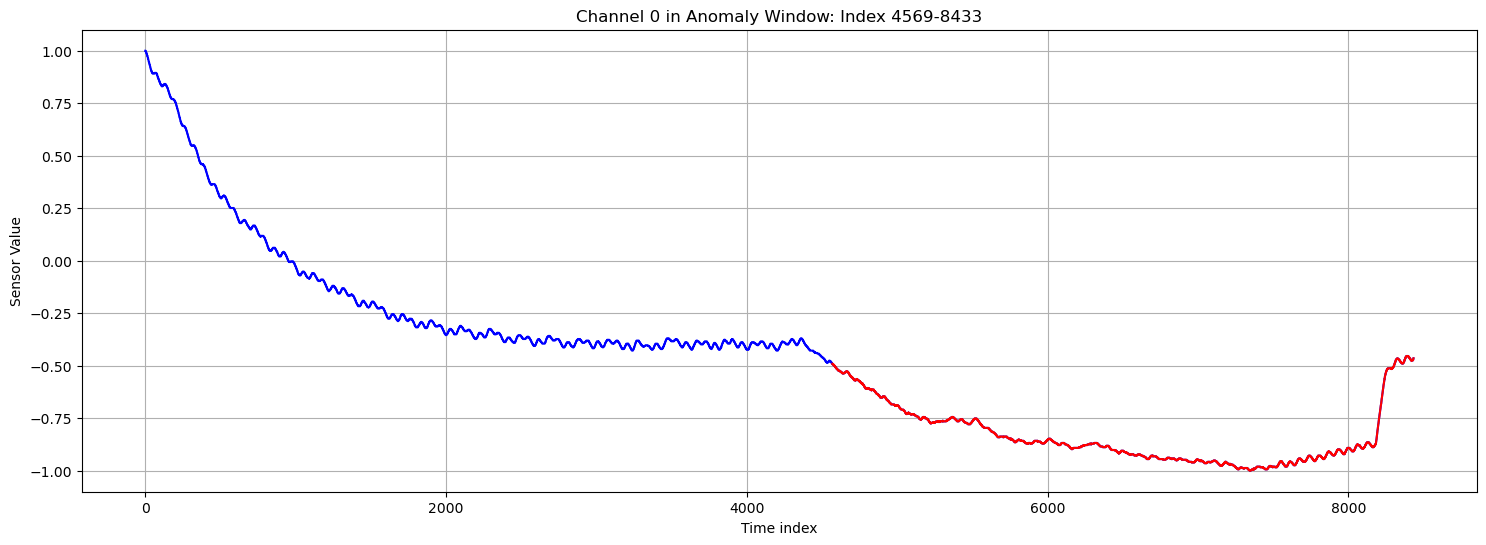

In [9]:
plt.figure(figsize=(18,6))

time_indices_anomlay = np.arange(anomaly_start,anomaly_end+1)
time_indices = np.arange(test_data.shape[0])

channel_0_data_anomaly = test_data[anomaly_start:anomaly_end+1,0]
channel_0_data = test_data[:,0]

plt.plot(time_indices,channel_0_data,color='blue')
plt.plot(time_indices_anomlay,channel_0_data_anomaly,color='red')
plt.title(f"Channel 0 in Anomaly Window: Index {anomaly_start}-{anomaly_end}")
plt.xlabel('Time index')
plt.ylabel('Sensor Value')
plt.grid(True)

plt.show()

This is a **contextual** anomaly as an anomalous trend appears in telemeyry.

## PREPROCESSING

1. EDA iniziale sui file train
2. controllo NaN / Inf
3. controllo feature costanti
4. rimozione feature costanti
5. split temporale train / validation
6. scaling fit solo sul train
7. PCA opzionale fit solo sul train
8. windowing

First we apply preprocessing pipeline on training set, then in test set.

In [10]:
smap_labels = df_SMAP_anomalies.copy()
smap_channels_ids = sorted(smap_labels['chan_id'].unique())

In [11]:
train_summary = []

for ch in smap_channels_ids:
    path = TRAIN_PATH + '/' + ch + '.npy'
    X = np.load(path)
    
    feature_std = np.nanstd(X, axis=0) #std among columns, nanstd ignores nan val
    
    train_summary.append({
        "channel_id": ch,
        "train_len": X.shape[0],
        "n_features": X.shape[1],
        "nan_count": int(np.isnan(X).sum()),
        "inf_count": int(np.isinf(X).sum()),
        "constant_features": int((feature_std == 0).sum()),
        "min": float(np.nanmin(X)),
        "max": float(np.nanmax(X)),
        "mean": float(np.nanmean(X)),
        "std": float(np.nanstd(X)),
    })

train_summary_df = pd.DataFrame(train_summary)
train_summary_df

,channel_id,train_len,n_features,nan_count,inf_count,constant_features,min,max,mean,std
0,A-1,2880,25,0,0,6,0.00,1.0,0.061654,0.240444
1,A-2,2648,25,0,0,7,-1.00,1.0,0.023143,0.186151
2,A-3,2736,25,0,0,7,-1.00,1.0,0.023542,0.173959
3,A-4,2690,25,0,0,7,-1.00,1.0,0.025349,0.163677
4,A-5,705,25,0,0,14,-1.00,1.0,-0.028584,0.224864
5,A-6,682,25,0,0,14,-1.00,1.0,-0.021383,0.200291
6,A-7,2879,25,0,0,15,-1.00,1.0,-0.011630,0.103913
7,A-8,762,25,0,0,15,-1.00,1.0,-0.007294,0.206191
8,A-9,762,25,0,0,15,-1.00,1.0,0.012211,0.204854
9,B-1,2435,25,0,0,13,-1.00,1.0,-0.035992,0.206671


The preliminary inspection of the SMAP training set shows that the data are generally clean from a missing-value perspective. No NaN or infinite values were found across the considered telemetry channels, so no imputation or removal of corrupted samples is required at this stage.

However, the dataset presents some relevant preprocessing issues. First, the telemetry streams have *different temporal* lengths: most channels contain around 2600–2880 time steps, while some channels are much shorter. This affects the windowing procedure, because shorter series generate fewer training windows and may be less informative for sequence-based models.

Second, all channels have 25 features, but several of these features *are constant over time* within each channel. In some cases, only a few features are constant, while in others almost all features do not vary. This is important because **constant features do not carry temporal information and may unnecessarily increase the dimensionality of the input**. They can also affect scaling and model training if not handled explicitly. --> `PCA`

A special case is represented by channels such as `D-12` and `D-13`, where all 25 features are constant over time. This does not necessarily mean that the whole matrix contains a single repeated value: different columns may have different constant values. However, from a temporal modeling perspective, these channels contain no dynamic information in the training set, and therefore require special attention.

In [12]:
train_summary_df.describe()

,train_len,n_features,nan_count,inf_count,constant_features,min,max,mean,std
count,54.000000,54.0,54.0,54.0,54.000000,54.000000,54.000000,54.000000,54.000000
mean,2555.629630,25.0,0.0,0.0,10.388889,-0.857037,0.962963,0.005461,0.200148
std,656.221784,0.0,0.0,0.0,5.137420,0.333747,0.190626,0.027075,0.041398
min,312.000000,25.0,0.0,0.0,6.000000,-1.000000,0.000000,-0.040000,0.074036
25%,2596.000000,25.0,0.0,0.0,7.000000,-1.000000,1.000000,-0.016257,0.175010
50%,2851.000000,25.0,0.0,0.0,7.000000,-1.000000,1.000000,0.003124,0.201878
75%,2880.000000,25.0,0.0,0.0,12.750000,-1.000000,1.000000,0.023131,0.240640
max,2881.000000,25.0,0.0,0.0,25.000000,0.000000,1.000000,0.063826,0.252260


The preprocessing pipeline is applied independently to each SMAP telemetry channel. First, the original training sequence is split into training and validation subsets using a temporal split, without shuffling, in order to avoid temporal leakage. Constant features are detected only on the training subset and then removed from both training and validation data. This avoids using information from the validation period during feature selection.

After removing constant features, the remaining variables are separated into binary and continuous features, using only the training subset to identify their type. Continuous features are standardized with a `StandardScaler` fitted only on the training subset, and the same transformation is then applied to the validation subset. Binary features are not standardized, since standardization would transform their original 0/1 representation into frequency-dependent real values. Instead, they are either kept as 0/1 variables or mapped to -1/1 in order to obtain a zero-centered binary encoding without distorting their binary nature.

Optionally, PCA can be fitted on the processed training data and then applied to the validation data, in order to reduce dimensionality while preserving a fixed fraction of the variance. PCA is also fitted only on the training subset to avoid information leakage.

Finally, both training and validation sequences are converted into overlapping temporal windows, which represent the input format required by sequence-based reconstruction or forecasting models.

In [13]:
def temporal_train_val_split(X, val_ratio=0.2):
    """
    Temporal split: first part for training, last part for validation.
    """
    split_idx = int(len(X) * (1 - val_ratio))
    X_train = X[:split_idx]
    X_val = X[split_idx:]
    
    return X_train, X_val

def detect_binary_features(X):
    """
    Detect binary columns using only the training split.
    A feature is considered binary if its unique values are contained in {0, 1}.
    """
    binary_mask = []

    for j in range(X.shape[1]):
        unique_values = np.unique(X[:, j])
        is_binary = set(unique_values).issubset({0, 1})
        binary_mask.append(is_binary)

    return np.array(binary_mask)

def make_windows(X, window_size=30, stride=1):
    """
    Convert a time series X of shape (T, d)
    into windows of shape (n_windows, window_size, d).
    """
    if len(X) < window_size:
        return None
    
    windows = []
    
    for start in range(0, len(X) - window_size + 1, stride):
        end = start + window_size
        windows.append(X[start:end])
    
    return np.stack(windows)

### Windowing

After the temporal split, each telemetry sequence is converted into overlapping time windows. This step is needed because the model should not observe each time step independently, but should instead learn short temporal patterns in the recent history of the signal.

Given a preprocessed sequence:

$X \in \mathbb{R}^{T \times d}$

where T is the number of time steps and d is the number of retained features, we construct windows of length w:

$W_t = [X_t, X_{t+1}, \dots, X_{t+w-1}]$

Each window therefore has shape:

$w \times d$

In this project, we use `window_size = 30` and `stride = 1`, meaning that consecutive windows overlap and are shifted by one time step. Therefore, the number of generated windows is:

$N_{\text{windows}} = T - w + 1$

#### Choice of the stride

In the windowing procedure, the stride controls how far the sliding window is shifted at each step. With `stride = 1`, two consecutive windows overlap almost completely and differ by only one time step. This produces the maximum number of training samples and preserves the highest temporal resolution.

This choice is suitable for anomaly detection because anomalies may be short, localized, or only visible in a narrow temporal region. Using a larger stride would reduce the number of windows and the computational cost, but it could also make the model less sensitive to short anomalous intervals or produce less precise anomaly localization.

Since the SMAP telemetry sequences are not extremely large, using `stride = 1` is a reasonable default choice for the first version of the pipeline. Larger strides can be considered as a computationally cheaper alternative and compared in an ablation study, for example by testing whether `stride = 5` significantly reduces performance while decreasing the number of generated windows.

For example, if a training split contains 2304 time steps and the window size is 30, the number of windows is:

$ 2304 - 30 + 1 = 2275 $

The final input shape for a channel is therefore:

$N_{\text{windows}} \times 30 \times d$

This representation allows the model to learn temporal dependencies and local patterns in the telemetry stream, which is essential for detecting anomalies that may not be visible from a single isolated time step.

In [14]:
def preprocess_single_channel(
    channel_id,
    train_path,
    val_ratio=0.2,
    window_size=250,
    stride=1,
    map_binary = True,
    drop_constant_features=False,
    use_pca=False,
    pca_variance=0.95
):
    # -------------------------
    # Load raw training sequence
    # -------------------------
    path = train_path + "/" + channel_id + ".npy"
    X_raw = np.load(path)
    
    # -------------------------
    # Basic checks
    # -------------------------
    nan_count = np.isnan(X_raw).sum()
    inf_count = np.isinf(X_raw).sum()
    
    if nan_count > 0:
        raise ValueError(f"{channel_id}: NaN values found.")
    
    if inf_count > 0:
        raise ValueError(f"{channel_id}: infinite values found.")
    
    # -------------------------
    # Temporal train/validation split
    # -------------------------
    X_train_raw, X_val_raw = temporal_train_val_split(X_raw, val_ratio=val_ratio)
    
    # -------------------------
    # Detect constant features on TRAIN only
    # -------------------------
    feature_std_train = np.std(X_train_raw, axis=0)
    constant_mask = feature_std_train == 0
    keep_mask = ~constant_mask
    
    n_constant_features = int(constant_mask.sum())
    constant_feature_indices = np.where(constant_mask)[0]
    kept_feature_indices = np.where(keep_mask)[0]
    
    # If all features are constant, skip this channel
    if keep_mask.sum() == 0:
        return None, {
            "channel_id": channel_id,
            "status": "skipped_all_features_constant",
            "raw_shape": X_raw.shape,
            "n_constant_features": n_constant_features,
            "constant_feature_indices": constant_feature_indices,
        }
    
    # -------------------------
    # Drop constant features
    # -------------------------
    if drop_constant_features:
        X_train_raw = X_train_raw[:, keep_mask]
        X_val_raw = X_val_raw[:, keep_mask]
    else:
        kept_feature_indices = np.arange(X_raw.shape[1])

    # -------------------------
    # Detect binary and continuous features on TRAIN only
    # -------------------------
    binary_mask = detect_binary_features(X_train_raw)
    continuous_mask = ~binary_mask
    binary_feature_indices_after_drop = np.where(binary_mask)[0]
    continuous_feature_indices_after_drop = np.where(continuous_mask)[0]
    n_binary_features = int(binary_mask.sum())
    n_continuous_features = int(continuous_mask.sum())
    
    # -------------------------
    # Scaling (continuos): fit only on train
    # -------------------------

    X_train_processed_parts = []
    X_val_processed_parts = []

    scaler = None

    if n_continuous_features > 0:
        scaler = StandardScaler()
        X_train_cont = X_train_raw[:, continuous_mask]
        X_val_cont = X_val_raw[:, continuous_mask]
        X_train_cont_scaled = scaler.fit_transform(X_train_cont)
        X_val_cont_scaled = scaler.transform(X_val_cont)
        X_train_processed_parts.append(X_train_cont_scaled)
        X_val_processed_parts.append(X_val_cont_scaled)

    # -------------------------
    # Mapping (bianry)
    # -------------------------

    if n_binary_features > 0:
        X_train_bin = X_train_raw[:, binary_mask]
        X_val_bin = X_val_raw[:, binary_mask]

        # Assicuriamoci che i valori anomali come -1 vengano mappati a 0 (One-Hot style)
        X_train_bin = np.where(X_train_bin == -1, 0.0, X_train_bin)
        X_val_bin = np.where(X_val_bin == -1, 0.0, X_val_bin)

        X_train_processed_parts.append(X_train_bin)
        X_val_processed_parts.append(X_val_bin)

    # Concatenate continuous-scaled + binary-encoded features
    X_train_processed = np.concatenate(X_train_processed_parts, axis=1)
    X_val_processed = np.concatenate(X_val_processed_parts, axis=1)
    
    # -------------------------
    # Optional PCA: fit only on train
    # -------------------------
    pca = None
    
    if use_pca:
        pca = PCA(n_components=pca_variance)
        X_train_processed = pca.fit_transform(X_train_processed)
        X_val_processed = pca.transform(X_val_processed)
        n_components_pca = pca.n_components_
        explained_variance = float(pca.explained_variance_ratio_.sum())
    else:
        X_train_processed = X_train_processed
        X_val_processed = X_val_processed
        n_components_pca = np.nan
        explained_variance = None
    
    # -------------------------
    # Windowing
    # -------------------------
    X_train_win = make_windows(X_train_processed, window_size=window_size, stride=stride)
    X_val_win = make_windows(X_val_processed, window_size=window_size, stride=stride)
    
    if X_train_win is None or X_val_win is None:
        return None, {
            "channel_id": channel_id,
            "status": "skipped_too_short_after_split",
            "raw_shape": X_raw.shape,
            "train_shape": X_train_processed.shape,
            "val_shape": X_val_processed.shape,
        }
    
    # -------------------------
    # Output dictionary
    # -------------------------
    data = {
        "X_train": X_train_win,
        "X_train_seq": X_train_processed,
        "X_val": X_val_win,
        "X_val_seq": X_val_processed,
        "scaler": scaler,
        "pca": pca,
        "kept_feature_indices": kept_feature_indices,
        "constant_feature_indices": constant_feature_indices,
        "continuous_mask": continuous_mask,
        "binary_mask": binary_mask,
    }
    
    info = {
        "channel_id": channel_id,
        "status": "ok",
        "raw_shape": X_raw.shape,
        "train_raw_shape": X_train_raw.shape,
        "val_raw_shape": X_val_raw.shape,
        "train_windows_shape": X_train_win.shape,
        "val_windows_shape": X_val_win.shape,
        "n_original_features": int(X_raw.shape[1]),
        "n_constant_features": n_constant_features,
        "n_kept_features": len(kept_feature_indices),
        "use_pca": use_pca,
        "n_components_after_pca": n_components_pca,
        "pca_explained_variance": explained_variance,
    }
    
    return data, info

We try first without PCA, then with PCA.

In [15]:
VAL_RATIO = 0.2
WINDOW_SIZE = 250
STRIDE = 1

USE_PCA = False          
PCA_VARIANCE = 0.95
DROP_CONSTANT_FEATURES = False

preprocessed_data = {}
preprocessing_summary = []

for ch in smap_channels_ids:
    data, info = preprocess_single_channel(
        channel_id=ch,
        train_path=TRAIN_PATH,
        val_ratio=VAL_RATIO,
        window_size=WINDOW_SIZE,
        stride=STRIDE,
        drop_constant_features=DROP_CONSTANT_FEATURES,
        use_pca=USE_PCA,
        pca_variance=PCA_VARIANCE
    )
    
    preprocessing_summary.append(info)
    
    if data is not None:
        preprocessed_data[ch] = data
        

preprocessing_summary_df = pd.DataFrame(preprocessing_summary)

if "constant_feature_indices" in preprocessing_summary_df.columns:
    preprocessing_summary_df = preprocessing_summary_df.drop(columns=["constant_feature_indices"])

display(preprocessing_summary_df)

,channel_id,status,raw_shape,train_raw_shape,val_raw_shape,train_windows_shape,val_windows_shape,n_original_features,n_constant_features,n_kept_features,use_pca,n_components_after_pca,pca_explained_variance,train_shape,val_shape
0,A-1,ok,"(2880, 25)","(2304, 25)","(576, 25)","(2055, 250, 25)","(327, 250, 25)",25.0,6.0,25.0,False,NaN,NaN,NaN,NaN
1,A-2,ok,"(2648, 25)","(2118, 25)","(530, 25)","(1869, 250, 25)","(281, 250, 25)",25.0,7.0,25.0,False,NaN,NaN,NaN,NaN
2,A-3,ok,"(2736, 25)","(2188, 25)","(548, 25)","(1939, 250, 25)","(299, 250, 25)",25.0,7.0,25.0,False,NaN,NaN,NaN,NaN
3,A-4,ok,"(2690, 25)","(2152, 25)","(538, 25)","(1903, 250, 25)","(289, 250, 25)",25.0,7.0,25.0,False,NaN,NaN,NaN,NaN
4,A-5,skipped_too_short_after_split,"(705, 25)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(564, 25)","(141, 25)"
5,A-6,skipped_too_short_after_split,"(682, 25)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(545, 25)","(137, 25)"
6,A-7,ok,"(2879, 25)","(2303, 25)","(576, 25)","(2054, 250, 25)","(327, 250, 25)",25.0,15.0,25.0,False,NaN,NaN,NaN,NaN
7,A-8,skipped_too_short_after_split,"(762, 25)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(609, 25)","(153, 25)"
8,A-9,skipped_too_short_after_split,"(762, 25)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(609, 25)","(153, 25)"
9,B-1,ok,"(2435, 25)","(1948, 25)","(487, 25)","(1699, 250, 25)","(238, 250, 25)",25.0,13.0,25.0,False,NaN,NaN,NaN,NaN


Each raw training sequence originally contains 25 features, but several features are constant over time within individual channels. These constant features were detected using only the training split and removed before scaling, in order to avoid adding non-informative dimensions to the model.

The temporal split preserves the chronological order of the data, using the first 80% of each sequence for training and the last 20% for validation. After feature filtering and standardization, the sequences were converted into overlapping windows of length 30. The resulting window shapes are consistent with the expected formula T - window_size + 1.

Most channels were successfully preprocessed. Channels `D-12` and `D-13` were skipped because all their features were constant in the training split, leaving no dynamic information to model. PCA was not applied in this preprocessing run, so the PCA-related columns are intentionally empty.

In [16]:
VAL_RATIO = 0.2
WINDOW_SIZE = 250
STRIDE = 1

USE_PCA = True          
PCA_VARIANCE = 0.95
DROP_CONSTANT_FEATURES = False

preprocessed_data_pca = {}
preprocessing_summary_pca = []

for ch in smap_channels_ids:
    data, info = preprocess_single_channel(
        channel_id=ch,
        train_path=TRAIN_PATH,
        val_ratio=VAL_RATIO,
        window_size=WINDOW_SIZE,
        stride=STRIDE,
        drop_constant_features=DROP_CONSTANT_FEATURES,
        use_pca=USE_PCA,
        pca_variance=PCA_VARIANCE
    )
    
    preprocessing_summary_pca.append(info)
    
    if data is not None:
        preprocessed_data_pca[ch] = data

pca_preprocessing_summary_df = pd.DataFrame(preprocessing_summary_pca)

if "constant_feature_indices" in pca_preprocessing_summary_df.columns:
    pca_preprocessing_summary_df = pca_preprocessing_summary_df.drop(columns=["constant_feature_indices"])

display(pca_preprocessing_summary_df)

,channel_id,status,raw_shape,train_raw_shape,val_raw_shape,train_windows_shape,val_windows_shape,n_original_features,n_constant_features,n_kept_features,use_pca,n_components_after_pca,pca_explained_variance,train_shape,val_shape
0,A-1,ok,"(2880, 25)","(2304, 25)","(576, 25)","(2055, 250, 5)","(327, 250, 5)",25.0,6.0,25.0,True,5.0,0.960289,NaN,NaN
1,A-2,ok,"(2648, 25)","(2118, 25)","(530, 25)","(1869, 250, 4)","(281, 250, 4)",25.0,7.0,25.0,True,4.0,0.973875,NaN,NaN
2,A-3,ok,"(2736, 25)","(2188, 25)","(548, 25)","(1939, 250, 4)","(299, 250, 4)",25.0,7.0,25.0,True,4.0,0.971879,NaN,NaN
3,A-4,ok,"(2690, 25)","(2152, 25)","(538, 25)","(1903, 250, 4)","(289, 250, 4)",25.0,7.0,25.0,True,4.0,0.971871,NaN,NaN
4,A-5,skipped_too_short_after_split,"(705, 25)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(564, 3)","(141, 3)"
5,A-6,skipped_too_short_after_split,"(682, 25)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(545, 3)","(137, 3)"
6,A-7,ok,"(2879, 25)","(2303, 25)","(576, 25)","(2054, 250, 1)","(327, 250, 1)",25.0,15.0,25.0,True,1.0,0.971438,NaN,NaN
7,A-8,skipped_too_short_after_split,"(762, 25)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(609, 2)","(153, 2)"
8,A-9,skipped_too_short_after_split,"(762, 25)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(609, 2)","(153, 2)"
9,B-1,ok,"(2435, 25)","(1948, 25)","(487, 25)","(1699, 250, 4)","(238, 250, 4)",25.0,13.0,25.0,True,4.0,0.952692,NaN,NaN


In this preprocessing run, PCA was applied after the temporal train/validation split, after removing constant features, and after standardization. This is the correct order, because the PCA basis must be fitted only on the training split in order to avoid information leakage from the validation period.

The table shows that PCA further reduces the dimensionality of each telemetry channel while preserving approximately 95% of the variance. For example, channel `A-1` goes from 25 original features to 19 non-constant features, and then to 10 PCA components. Similarly, `A-5` goes from 25 original features to 11 retained features and then to 6 PCA components.

The column `pca_explained_variance` confirms that the retained PCA components preserve the target amount of variance. In most channels, the explained variance is slightly above 0.95, as expected. Some channels, such as `G-7` and `T-1`, reach an explained variance of 1.0 because they already have very few non-constant features after feature filtering.

The resulting window shapes reflect the PCA-reduced feature space. For instance, `A-1` has training windows of shape `(2275, 30, 10)`, meaning 2275 windows, each containing 30 time steps and 10 PCA components. Therefore, the temporal dimension is preserved, while the feature dimension is compressed.

Channels `D-12` and `D-13` are still skipped because all their original features are constant in the training split. Since no informative feature remains after constant-feature removal, PCA cannot be applied to these channels.

Overall, PCA provides a more compact representation of the telemetry streams, reducing input dimensionality while retaining most of the variance. This can reduce model complexity and computational cost, **but it should be compared against the non-PCA version to check whether the dimensionality reduction preserves anomaly-relevant information.**

Now we move to test_data preprocessing.

### Test label construction and window alignment

The function `build_binary_labels` converts the anomaly intervals provided in the metadata into a point-wise binary label vector. The original labels are given as intervals `[start, end]`, meaning that all time steps between `start` and `end` are anomalous. Therefore, for a test sequence of length T, the function creates a vector:

$y \in \{0,1\}^{T}$

where $y_t = 1$ if time step t belongs to an anomalous interval, and $y_t = 0$ otherwise. The interval boundaries are clipped to remain inside the valid range of the test sequence.

In [17]:
def parse_anomaly_sequences(x):
    """
    Convert anomaly_sequences from string format to Python list.
    """
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x

def build_binary_labels(length, anomaly_sequences):
    """
    Convert anomaly intervals into a binary vector.
    1 = anomalous timestep, 0 = normal timestep.
    """
    y = np.zeros(length, dtype=int)

    for start, end in anomaly_sequences:
        start = max(0, int(start))
        end = min(length - 1, int(end))
        y[start:end + 1] = 1

    return y

In [18]:
def preprocess_test_channel(
    channel_id,
    test_path,
    labels_df,
    train_preprocessed_data,
    window_size=30,
    stride=1,
):
    # If the channel was skipped during train preprocessing, skip it also in test
    if channel_id not in train_preprocessed_data:
        return None, {
            "channel_id": channel_id,
            "status": "skipped_no_train_preprocessing"
        }

    # -------------------------
    # Load raw test sequence
    # -------------------------
    path = test_path + "/" + channel_id + ".npy"
    X_test_raw = np.load(path)

    # -------------------------
    # Basic checks
    # -------------------------
    nan_count = np.isnan(X_test_raw).sum()
    inf_count = np.isinf(X_test_raw).sum()

    if nan_count > 0:
        raise ValueError(f"{channel_id}: NaN values found in test data.")

    if inf_count > 0:
        raise ValueError(f"{channel_id}: infinite values found in test data.")

    # -------------------------
    # Retrieve preprocessing fitted/defined on train
    # -------------------------
    train_info = train_preprocessed_data[channel_id]

    kept_feature_indices = train_info["kept_feature_indices"]
    binary_mask = train_info["binary_mask"]
    continuous_mask = train_info["continuous_mask"]
    scaler = train_info["scaler"]
    pca = train_info["pca"]

    # -------------------------
    # Apply same feature selection used on train
    # -------------------------
    X_test_selected = X_test_raw[:, kept_feature_indices]

    # -------------------------
    # Apply same continuous/binary preprocessing
    # -------------------------
    X_test_processed_parts = []

    # Continuous features: transform using scaler fitted on train
    if continuous_mask.sum() > 0:
        X_test_cont = X_test_selected[:, continuous_mask]
        X_test_cont_scaled = scaler.transform(X_test_cont)
        X_test_processed_parts.append(X_test_cont_scaled)

    # Binary features: map everything to {0,1}
    if binary_mask.sum() > 0:
        X_test_bin = X_test_selected[:, binary_mask]

        X_test_bin = np.where(X_test_bin == -1, 0.0, X_test_bin)

        X_test_processed_parts.append(X_test_bin)

    X_test_processed = np.concatenate(X_test_processed_parts, axis=1)

    # -------------------------
    # Apply PCA fitted on train, if present
    # -------------------------
    if pca is not None:
        X_test_processed = pca.transform(X_test_processed)
        use_pca = True
    else:
        use_pca = False

    # -------------------------
    # Windowing
    # -------------------------
    X_test_win = make_windows(
        X_test_processed,
        window_size=window_size,
        stride=stride
    )

    if X_test_win is None:
        return None, {
            "channel_id": channel_id,
            "status": "skipped_test_too_short",
            "raw_shape": X_test_raw.shape,
            "processed_shape": X_test_processed.shape
        }

    # -------------------------
    # Retrieve and merge anomaly intervals
    # -------------------------
    rows = labels_df[labels_df["chan_id"] == channel_id]

    if len(rows) == 0:
        raise ValueError(f"{channel_id}: no labels found.")

    anomaly_sequences = []
    for seq in rows["anomaly_sequences"]:
        anomaly_sequences.extend(seq)

    # -------------------------
    # Build raw timestep labels
    # -------------------------
    y_test_raw = build_binary_labels(
        length=len(X_test_raw),
        anomaly_sequences=anomaly_sequences
    )

    y_test = y_test_raw[window_size:]


    # -------------------------
    # Output
    # -------------------------
    data = {
        "X_test": X_test_win,
        "X_test_seq": X_test_processed,
        "y_test": y_test,
        "anomaly_sequences": anomaly_sequences,
    }

    info = {
        "channel_id": channel_id,
        "status": "ok",
        "raw_shape": X_test_raw.shape,
        "processed_shape": X_test_processed.shape,
        "test_windows_shape": X_test_win.shape,
        "y_test_shape": y_test.shape,
        "n_anomaly_points": int(y_test.sum()),
        "anomaly_ratio": float(y_test.mean()),
        "n_binary_features": int(binary_mask.sum()),
        "n_continuous_features": int(continuous_mask.sum()),
        "use_pca": use_pca,
    }

    return data, info

Again, first with PCA then without.

In [19]:
df_SMAP_anomalies_clean = df_SMAP_anomalies.copy()

df_SMAP_anomalies_clean["anomaly_sequences"] = (
    df_SMAP_anomalies_clean["anomaly_sequences"].apply(parse_anomaly_sequences))

test_preprocessed_data = {}
test_preprocessing_summary = []

for ch in smap_channels_ids:
    data, info = preprocess_test_channel(
        channel_id=ch,
        test_path=TEST_PATH,
        labels_df= df_SMAP_anomalies_clean,
        train_preprocessed_data=preprocessed_data,
        window_size=WINDOW_SIZE,
        stride=STRIDE
    )

    test_preprocessing_summary.append(info)

    if data is not None:
        test_preprocessed_data[ch] = data

test_preprocessing_summary_df = pd.DataFrame(test_preprocessing_summary)
display(test_preprocessing_summary_df)

,channel_id,status,raw_shape,processed_shape,test_windows_shape,y_test_shape,n_anomaly_points,anomaly_ratio,n_binary_features,n_continuous_features,use_pca
0,A-1,ok,"(8640, 25)","(8640, 25)","(8391, 250, 25)","(8390,)",85.0,0.010131,24.0,1.0,False
1,A-2,ok,"(7914, 25)","(7914, 25)","(7665, 250, 25)","(7664,)",111.0,0.014483,24.0,1.0,False
2,A-3,ok,"(8205, 25)","(8205, 25)","(7956, 250, 25)","(7955,)",186.0,0.023382,24.0,1.0,False
3,A-4,ok,"(8080, 25)","(8080, 25)","(7831, 250, 25)","(7830,)",111.0,0.014176,24.0,1.0,False
4,A-5,skipped_no_train_preprocessing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,A-6,skipped_no_train_preprocessing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,A-7,ok,"(8631, 25)","(8631, 25)","(8382, 250, 25)","(8381,)",2401.0,0.286481,24.0,1.0,False
7,A-8,skipped_no_train_preprocessing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,A-9,skipped_no_train_preprocessing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,B-1,ok,"(8044, 25)","(8044, 25)","(7795, 250, 25)","(7794,)",71.0,0.009110,24.0,1.0,False


The test preprocessing is consistent with the transformations learned during the training preprocessing. For each telemetry channel, the same feature selection obtained from the training split is applied to the test sequence. For example, channel `A-1` is reduced from 25 original features to 19 retained features, matching the 6 constant features detected in the training data.

No preprocessing step is fitted on the test set. The scaler, the retained feature indices, and the optional PCA transformation are taken from the training preprocessing and only applied to the test data. This avoids information leakage and simulates a realistic deployment setting, where future telemetry must be processed using parameters estimated from past data.

The windowing step is also consistent with the training pipeline. With `window_size = 30` and `stride = 1`, a test sequence of length T produces $T - 30 + 1$ windows. For instance, `A-1` has 8640 test time steps and therefore produces 8611 windows, each with shape $30 \times 19$.

Channels `D-12` and `D-13` are skipped because they were already excluded during training preprocessing: all their features were constant in the training split, leaving no dynamic information to model.

Finally, the anomaly intervals provided in the metadata are converted into binary timestep labels and then aligned with the generated windows. Since `label_mode = "last"` is used, each window receives the label of its final timestep. The resulting anomaly ratios show strong variability across telemetry channels, confirming that the evaluation should not rely on accuracy alone but should consider precision, recall, F1-score, and possibly per-channel analysis.

In [20]:
test_preprocessed_data_pca = {}
test_preprocessing_summary_pca = []

for ch in smap_channels_ids:
    data, info = preprocess_test_channel(
        channel_id=ch,
        test_path=TEST_PATH,
        labels_df= df_SMAP_anomalies_clean,
        train_preprocessed_data=preprocessed_data_pca,
        window_size=WINDOW_SIZE,
        stride=STRIDE
    )

    test_preprocessing_summary_pca.append(info)

    if data is not None:
        test_preprocessed_data_pca[ch] = data

pca_test_preprocessing_summary_df = pd.DataFrame(test_preprocessing_summary_pca)
display(pca_test_preprocessing_summary_df)

,channel_id,status,raw_shape,processed_shape,test_windows_shape,y_test_shape,n_anomaly_points,anomaly_ratio,n_binary_features,n_continuous_features,use_pca
0,A-1,ok,"(8640, 25)","(8640, 5)","(8391, 250, 5)","(8390,)",85.0,0.010131,24.0,1.0,True
1,A-2,ok,"(7914, 25)","(7914, 4)","(7665, 250, 4)","(7664,)",111.0,0.014483,24.0,1.0,True
2,A-3,ok,"(8205, 25)","(8205, 4)","(7956, 250, 4)","(7955,)",186.0,0.023382,24.0,1.0,True
3,A-4,ok,"(8080, 25)","(8080, 4)","(7831, 250, 4)","(7830,)",111.0,0.014176,24.0,1.0,True
4,A-5,skipped_no_train_preprocessing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,A-6,skipped_no_train_preprocessing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,A-7,ok,"(8631, 25)","(8631, 1)","(8382, 250, 1)","(8381,)",2401.0,0.286481,24.0,1.0,True
7,A-8,skipped_no_train_preprocessing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,A-9,skipped_no_train_preprocessing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,B-1,ok,"(8044, 25)","(8044, 4)","(7795, 250, 4)","(7794,)",71.0,0.009110,24.0,1.0,True


Compared to the non-PCA test preprocessing, the only additional transformation here is the projection onto the PCA space learned from the corresponding training split. The test data are therefore not only filtered using the same retained features and standardized with the train-fitted scaler, but also transformed using the PCA model fitted on the training data.

This is visible in the `processed_shape` and `test_windows_shape` columns. For example, `A-1` is reduced from 25 original features to 10 PCA components, producing test windows of shape `(8611, 30, 10)`. In the non-PCA version, the same channel retained 19 features after constant-feature removal. Thus, PCA further compresses the input representation while preserving the temporal structure of the data.

The anomaly labels and window alignment remain unchanged with respect to the non-PCA version. The number of anomalous raw points and anomalous windows is therefore the same, because PCA only affects the feature representation, not the temporal indexing or the label construction.

Channels `D-12` and `D-13` are still skipped because they were already excluded during training preprocessing. Since no informative non-constant features were available for these channels, no scaler or PCA transformation was fitted for them.

In [21]:
# Final checks

print('train_no_pca:',len(preprocessed_data))
print('train_pca:',len(preprocessed_data_pca))
print()
print('test_no_pca:',len(test_preprocessed_data))
print('test_pca:',len(test_preprocessed_data_pca))
print()
print(set(preprocessed_data.keys()) == set(test_preprocessed_data.keys()))
print(set(preprocessed_data_pca.keys()) == set(test_preprocessed_data_pca.keys()))

train_no_pca: 48
train_pca: 48

test_no_pca: 48
test_pca: 48

True
True


In [22]:
# check for a channel dimensions

ch = list(preprocessed_data.keys())[0]
print(preprocessed_data[ch]["X_train"].shape)
print(preprocessed_data[ch]["X_val"].shape)
print(test_preprocessed_data[ch]["X_test"].shape)
print(test_preprocessed_data[ch]["y_test"].shape)

print()

ch_pca = list(preprocessed_data_pca.keys())[0]
print(preprocessed_data[ch_pca]["X_train"].shape)
print(preprocessed_data[ch_pca]["X_val"].shape)
print(test_preprocessed_data[ch_pca]["X_test"].shape)
print(test_preprocessed_data[ch_pca]["y_test"].shape)

(2055, 250, 25)
(327, 250, 25)
(8391, 250, 25)
(8390,)

(2055, 250, 25)
(327, 250, 25)
(8391, 250, 25)
(8390,)


### Non-Parametric Dynamic Thresholding (Hundman et al., 2018)

In aerospace anomaly detection, static thresholds are often inadequate due to the non-stationary and noisy nature of spacecraft telemetry. To address this, we implement the dynamic, non-parametric thresholding approach proposed by the NASA Jet Propulsion Laboratory (JPL).

Instead of assuming a Gaussian distribution of errors , this method evaluates a rolling historical window of smoothed errors ($h = 2100$ steps) and dynamically calculates a threshold $\epsilon$ that maximizes the percentage decrease in both the mean and standard deviation of the "normal" background noise, while penalizing the creation of too many isolated anomaly sequences ($|E_{seq}|$).

The optimization function is defined as:


$$\text{argmax}(\epsilon) = \frac{\frac{\Delta\mu(e_s)}{\mu(e_s)} + \frac{\Delta\sigma(e_s)}{\sigma(e_s)}}{|e_a| + |E_{seq}|^2}$$

where $\epsilon = \mu(e_s) + z \cdot \sigma(e_s)$ is tested over a grid of $z$ values.

##### Downlink Simulation (Batch Processing)

To mimic the real-world operational environment of the SMAP satellite, the Test Set is not evaluated globally. Instead, it is processed in discrete **70-minute batches**, simulating periodic data downlinks.

1. **Initialization:** The last $h$ steps of the Validation Set are used to "warm up" the historical buffer.


2. **Dynamic Update:** For each new 70-minute batch, a new optimal threshold $\epsilon$ is calculated based on the previous $h$ minutes.


3. **Application:** The calculated threshold is applied *only* to the current batch.


4. **Sliding Window:** The batch is added to the historical buffer, and the oldest data is discarded (FIFO).



This continuous adjustment ensures the threshold "chases" the physiological variations of the spacecraft, minimizing false positives.

In [23]:
from sklearn.metrics import average_precision_score

def get_anomaly_sequences(binary_array):                                    #<----------- CHANGED
    """
    Return contiguous anomalous intervals from a binary array.
    Example:
        [0, 1, 1, 0, 1] -> [(1, 2), (4, 4)]
    """

    binary_array = np.asarray(binary_array).astype(int)
    padded = np.pad(binary_array, (1, 1), mode="constant", constant_values=0)
    diff = np.diff(padded)
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1

    return list(zip(starts, ends))

def prune_anomalies_by_error_drop(smoothed_errors, y_pred, p=0.13):         #<--------- ADDED
    """
    Prune anomalous sequences following the logic of Hundman et al.
    Parameters
    ----------
    smoothed_errors : array-like
        EWMA-smoothed forecasting errors.
    y_pred : array-like
        Binary anomaly predictions before pruning.
    p : float
        Minimum percentage decrease required to keep only the strongest
        anomalous sequences. The paper uses p = 0.13.
    Returns
    -------
    y_pruned : np.ndarray
        Binary anomaly predictions after pruning.
    """

    smoothed_errors = np.asarray(smoothed_errors)
    y_pred = np.asarray(y_pred).astype(int)
    pred_sequences = get_anomaly_sequences(y_pred)
    
    if len(pred_sequences) == 0:
        return y_pred.copy()

    # Maximum smoothed error inside each predicted anomalous sequence
    seq_maxima = []

    for seq_id, (start, end) in enumerate(pred_sequences):
        seq_max_error = np.max(smoothed_errors[start:end + 1])
        seq_maxima.append((seq_max_error, seq_id))

    # Sort anomalous sequences by decreasing maximum error
    seq_maxima = sorted(seq_maxima, key=lambda x: x[0], reverse=True)

    # Maximum error among points currently classified as nominal
    nominal_errors = smoothed_errors[y_pred == 0]

    if len(nominal_errors) > 0:
        max_nominal_error = np.max(nominal_errors)
    else:
        max_nominal_error = 0.0

    # Add the strongest nominal value as reference lower bound
    ordered_values = [value for value, _ in seq_maxima] + [max_nominal_error]
    keep_seq_ids = set()

    # Search for the first sufficiently large percentage drop
    for i in range(1, len(ordered_values)):
        previous_value = ordered_values[i - 1]
        current_value = ordered_values[i]
        if previous_value <= 0:
            continue

        decrease = (previous_value - current_value) / previous_value
        if decrease >= p:
            # Keep all anomalous sequences before the drop
            keep_seq_ids = {seq_id for _, seq_id in seq_maxima[:i]}
            break

    # If no sufficiently large drop is found, prune all candidate sequences
    y_pruned = np.zeros_like(y_pred)

    if len(keep_seq_ids) == 0:
        print(f"No sufficiently large error drop found with p={p}. No pruning has been performed.") # Instead of setting all to 0 (no anomalies)
        return y_pred.copy()
    
    for seq_id in keep_seq_ids:
        start, end = pred_sequences[seq_id]
        y_pruned[start:end + 1] = 1

    return y_pruned

In [24]:
def find_hundman_threshold(history_errors, z_values=np.arange(2.5, 10.5, 0.5)):
    """
    Implementazione esatta dell'equazione di massimizzazione non-parametrica 
    di Hundman et al. (2018).
    Trova la soglia epsilon che massimizza il calo di media e deviazione standard.
    """
    mu = np.mean(history_errors)
    sigma = np.std(history_errors)
    
    # Sicurezza contro le divisioni per zero
    if mu == 0: mu = 1e-10
    if sigma == 0: sigma = 1e-10

    best_epsilon = None
    max_metric = -np.inf

    # Testiamo tutti i multipli Z (2.5, 3.0, 3.5 ... 10.0)
    for z in z_values:
        epsilon = mu + z * sigma

        # Troviamo quali valori storici verrebbero classificati come anomalie
        is_anomalous = history_errors > epsilon
        e_a_count = np.sum(is_anomalous) # Corrisponde a |e_a| nel paper

        # Se questa soglia non trova anomalie, o se scarta tutto, la ignoriamo
        if e_a_count == 0 or e_a_count == len(history_errors):
            continue

        # Calcoliamo media e std degli errori "normali" (sotto la soglia)
        nominal_errors = history_errors[~is_anomalous]
        mu_nom = np.mean(nominal_errors)
        sigma_nom = np.std(nominal_errors)

        # Calcoliamo i cali assoluti (Delta)
        delta_mu = mu - mu_nom
        delta_sigma = sigma - sigma_nom

        # Calcoliamo il numero di SEQUENZE anomale |E_seq|
        # Usiamo np.diff per trovare i punti in cui l'array passa da 0 a 1
        padded = np.pad(is_anomalous.astype(int), (1, 1), mode='constant')
        transitions = np.diff(padded)
        E_seq_count = np.sum(transitions == 1)

        # --- L'EQUAZIONE PRINCIPALE DEL PAPER ---
        numerator = (delta_mu / mu) + (delta_sigma / sigma)
        denominator = e_a_count + (E_seq_count ** 2)
        
        metric = numerator / denominator

        # Aggiorniamo la soglia migliore se la metrica sale
        if metric > max_metric:
            max_metric = metric
            best_epsilon = epsilon

    # Caso limite: se nessun 'z' genera una separazione valida,
    # impostiamo una soglia altissima (uguale al max dell'history) per silenziare allarmi.
    if best_epsilon is None:
        best_epsilon = np.max(history_errors) + 1e-6

    return best_epsilon

def apply_dynamic_thresholding(                                         #<-------- CHANGED     
    val_smoothed,
    test_smoothed,
    h=2100,
    batch_size=70,
    pruning=False,
    p=0.13
):
    """
    Dynamic non-parametric thresholding.

    Validation smoothed errors are used as the initial historical buffer.
    Test errors are processed in batches. For each batch, the threshold is
    computed only from past errors.

    If pruning=True, predicted anomalous sequences are pruned after the full
    test sequence has been thresholded.
    """
    y_pred = np.zeros_like(test_smoothed, dtype=int)

    history = list(val_smoothed[-h:]) if len(val_smoothed) > 0 else []
    thresholds_history = []

    for start in range(0, len(test_smoothed), batch_size):
        end = start + batch_size
        current_batch = test_smoothed[start:end]

        hist_array = np.array(history)

        if len(hist_array) < 100:
            dynamic_threshold = np.max(current_batch) + 1e-6
        else:
            dynamic_threshold = find_hundman_threshold(hist_array)

        thresholds_history.append(dynamic_threshold)

        batch_predictions = (current_batch > dynamic_threshold).astype(int)
        y_pred[start:end] = batch_predictions

        history.extend(current_batch)
        history = history[-h:]

    if pruning:
        y_pred = prune_anomalies_by_error_drop(
            smoothed_errors=test_smoothed,
            y_pred=y_pred,
            p=p
        )

    return y_pred, np.array(thresholds_history)

------->ADDED<---------

After dynamic thresholding, predicted anomalous points are grouped into contiguous sequences and a pruning step is applied as an offline post-processing stage. This pruning uses the maximum smoothed error of each predicted sequence to remove weak candidates. Therefore, pruning is not strictly online, while threshold computation itself remains causal because each batch threshold is computed only from past errors.

### Exponentially Weighted Moving Average (EWMA) Smoothing

Machine learning predictions on noisy time-series data often produce sharp, isolated spikes in prediction errors, even during nominal spacecraft operations. To prevent these normal fluctuations from triggering false anomaly alerts, we apply an **Exponentially Weighted Moving Average (EWMA)** to the raw prediction errors before thresholding.

Unlike a simple moving average, EWMA applies weighting factors that decrease exponentially. This means recent errors have the highest impact, while older errors still contribute but with diminishing influence. The formula is:


$$e_s^{(t)} = \alpha \cdot e^{(t)} + (1 - \alpha) \cdot e_s^{(t-1)}$$


where $e_s^{(t)}$ is the smoothed error, $e^{(t)}$ is the raw error, and $\alpha$ is the smoothing factor (inversely related to the span).

It acts as a low-pass filter, flattening isolated spikes that last only one or two minutes.

If an error persists over several minutes (a true anomaly), the smoothed curve accumulates the error and rises steadily until it breaches the dynamic threshold, effectively separating real issues from transient noise.


In [25]:
def apply_ewma_smoothing(errors, span=2100):
    """
    Applica la media mobile esponenzialmente ponderata (EWMA) 
    per smorzare i picchi fisiologici degli errori.
    """
    return pd.Series(errors).ewm(span=span, adjust=False).mean().values

def flatten_windows(X):
    """
    Converte un array 3D di finestre temporali in un array 2D compatibile con scikit-learn.
    
    Dimensioni input: (n_samples, window_size, n_features)
    Dimensioni output: (n_samples, window_size * n_features)
    """
    # Assicuriamoci che l'input sia un array NumPy
    X_np = np.asarray(X)
    
    # Se l'array è già 2D (o meno), lo restituiamo così com'è per evitare errori
    if X_np.ndim <= 2:
        return X_np
        
    # Otteniamo il numero di campioni (la prima dimensione)
    n_samples = X_np.shape[0]
    
    # Reshape: manteniamo n_samples e compattiamo tutto il resto con -1
    return X_np.reshape(n_samples, -1)


### Sequence-Based Evaluation Metrics (Hundman et al., 2018)

Standard point-wise evaluation metrics heavily penalize models in time-series anomaly detection. If a model detects a 100-minute anomaly sequence only 5 minutes after it starts, point-wise metrics count 95 True Positives and 5 False Negatives, severely degrading the Recall.

To reflect true operational success, we implement the **Sequence-Based Evaluation** logic proposed by Hundman et al. (2018). Instead of evaluating individual timesteps, the algorithm groups continuous anomalous points into discrete sequences and applies three strict rules:

1. **True Positive (TP):** A true positive is recorded if *any* portion of a predicted anomaly sequence overlaps with a true labeled anomaly sequence. Only one TP is recorded per true anomaly, even if the model triggers multiple fragmented alerts within that same true sequence.


2. **False Negative (FN):** If a true labeled sequence has zero overlapping predicted sequences, it is recorded as a false negative.


3. **False Positive (FP):** Any predicted sequence that does not overlap with any true anomalous region is recorded as a false positive.

From these counts, we calculate the standard performance metrics: 

**Precision** measures how many predicted anomalies are actually anomalous. It is useful to quantify the reliability of the alarms:

$\text{precision} = \frac{TP}{TP + FP}$

**Recall** measures how many true anomalies are detected. It is important because missing an anomalous telemetry interval may be more critical than raising a false alarm:

$\text{recall} = \frac{TP}{TP + FN}$

**F1-score** combines precision and recall into a single value, providing a balanced measure when both false positives and false negatives matter:

$F1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$

**PR-AUC** evaluates the quality of the continuous anomaly scores across different possible thresholds. This is useful because the final performance can depend strongly on the selected threshold, and precision-recall curves are better suited than ROC curves when the positive class is rare.

The `predicted_anomaly_ratio` is also reported as a diagnostic quantity. It indicates the fraction of windows classified as anomalous and helps identify degenerate cases where a model predicts almost everything as normal or almost everything as anomalous.


In [26]:
def evaluate_sequences(y_true, y_pred, y_scores):
    """
    Valuta le previsioni usando le regole per sequenze di Hundman et al. (2018)
    e calcola metriche operative globali (PR-AUC e Anomaly Ratio).
    
    Parametri:
    y_true: array binario delle etichette reali allineate (punto per punto).
    y_pred: array binario delle previsioni (Anomaly Score > Soglia).
    y_scores: array continuo degli Anomaly Scores originali (per PR-AUC).
    """
    # 1. ESTREZIONE DELLE SEQUENZE
    true_seqs = get_anomaly_sequences(y_true)
    pred_seqs = get_anomaly_sequences(y_pred)
    
    TP = 0
    FP = 0
    
    # Set per tenere traccia delle anomalie vere già "scoperte"
    detected_true_seqs = set()
    
    # 2. LOGICA HUNDMAN PER LE SEQUENZE
    for p_start, p_end in pred_seqs:
        overlap_found = False
        
        for i, (t_start, t_end) in enumerate(true_seqs):
            # Condizione di sovrapposizione
            if max(p_start, t_start) <= min(p_end, t_end):
                overlap_found = True
                detected_true_seqs.add(i)
                break
                
        # Regola 3: Falso Positivo se non c'è sovrapposizione
        if not overlap_found:
            FP += 1
            
    # Regola 1: Veri Positivi
    TP = len(detected_true_seqs)
    
    # Regola 2: Falsi Negativi
    FN = len(true_seqs) - TP
    
    # 3. CALCOLO METRICHE SEQUENZIALI
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    # 4. CALCOLO METRICHE OPERATIVE GLOBALI
    # PR-AUC viene calcolato sui punteggi continui originali rispetto alle etichette originali
    pr_auc = average_precision_score(y_true, y_scores)
    
    # Ratio: percentuale di timestep previsti come anomali rispetto al totale
    predicted_anomaly_ratio = float(y_pred.mean())
    
    return {
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "pr_auc": pr_auc,
        "predicted_anomaly_ratio": predicted_anomaly_ratio
    }

### Visualization and Evaluation Toolkit

The following code cell defines a comprehensive suite of plotting functions designed to visually evaluate, interpret, and compare the performance of our anomaly detection models on the SMAP dataset. Rather than relying solely on raw metrics, these tools help us understand exactly how and why a model is behaving in a certain way.

**`plot_scores_with_anomaly_regions`** visualizes the temporal evolution of the model's anomaly scores against the ground truth. By plotting the scores as a continuous line alongside a dashed red threshold and highlighting the actual anomalous windows with shaded background bands, it provides an immediate visual check. This approach makes it incredibly easy to spot false positives—when peaks occur outside the shaded bands—or false negatives, where the score drops inappropriately inside them.

**`plot_score_distribution`** evaluates the model's ability to separate normal data from anomalous data by displaying overlapping histograms. It maps out the frequency distribution of anomaly scores for both classes, giving a clear picture of the model's discriminative power. Distinct, separated distributions indicate excellent performance, whereas heavily overlapping areas suggest the model is struggling to differentiate the two states.

**`plot_pr_curve`** provides the gold-standard visual metric for highly imbalanced datasets like SMAP. It generates a Precision-Recall curve computed across all possible thresholds and reports the Average Precision (AP). This graph visually demonstrates the critical trade-off between how many true anomalies the model can catch (Recall) before it begins generating an unacceptable number of false alarms (Precision).

**`plot_model_comparison_pca_vs_no_pca`** is designed for visual A/B testing between two different model setups, such as raw data versus PCA-engineered features. To ensure a fair and readable comparison, it Min-Max normalizes both sets of scores and their respective thresholds to a standard `[0, 1]` range. Overlaid on the ground truth background, it allows you to instantly determine if a specific preprocessing step amplifies the anomaly signal or flattens out useful information compared to the baseline.

**`plot_iforest_2d_mesh`** explores the topological decision space of spatial models like Isolation Forest. It projects high-dimensional data onto a 2D plane using a secondary PCA strictly for visualization, creating a contour map that represents the anomaly score surface. By plotting normal windows as small dots and true anomalies as large stars, it provides powerful geometric intuition. This reveals whether true anomalies are genuinely pushed to the isolated margins of the feature space or if they remain frustratingly hidden deep within dense clusters of normal data.

In [27]:
def plot_scores_with_anomaly_regions(
    scores,
    y_true,
    threshold,
    channel_id,
    model_name,
    xlabel="Time index",
    score_label="Anomaly score",
    figsize=(16, 5)
):
    plt.figure(figsize=figsize)

    plt.plot(scores, label=f"{model_name} anomaly score", linewidth=1)
    plt.axhline(threshold, linestyle="--", label="Threshold", color="red")

    in_anomaly = False
    start = None

    for i, value in enumerate(y_true):
        if value == 1 and not in_anomaly:
            start = i
            in_anomaly = True
        elif value == 0 and in_anomaly:
            plt.axvspan(start, i - 1, alpha=0.2)
            in_anomaly = False

    if in_anomaly:
        plt.axvspan(start, len(y_true) - 1, alpha=0.2)

    plt.title(f"{model_name} scores with true anomaly regions - Channel {channel_id}")
    plt.xlabel(xlabel)
    plt.ylabel(score_label)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_score_distribution(
    scores,
    y_true,
    threshold,
    channel_id,
    model_name,
    bins=50,
    figsize=(8, 5)
):
    normal_scores = scores[y_true == 0]
    anomaly_scores = scores[y_true == 1]

    plt.figure(figsize=figsize)

    plt.hist(normal_scores, bins=bins, alpha=0.6, label="Normal samples")
    plt.hist(anomaly_scores, bins=bins, alpha=0.6, label="Anomalous samples")
    plt.axvline(threshold, linestyle="--", label="Threshold", color="red")

    plt.title(f"{model_name} score distribution - Channel {channel_id}")
    plt.xlabel("Anomaly score")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_pr_curve(
    scores,
    y_true,
    channel_id,
    model_name,
    figsize=(6, 5)
):
    precision, recall, _ = precision_recall_curve(y_true, scores)
    ap = average_precision_score(y_true, scores)

    plt.figure(figsize=figsize)

    plt.plot(recall, precision, label=f"AP = {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall curve - {model_name} - Channel {channel_id}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_model_comparison_pca_vs_no_pca(
    channel_id,
    scores_no_pca,
    scores_pca,
    y_true,
    threshold_no_pca,
    threshold_pca,
    model_name,
    figsize=(16, 5)
):
    s_no = scores_no_pca
    s_pca = scores_pca

    s_no_norm = (s_no - s_no.min()) / (s_no.max() - s_no.min() + 1e-12)
    s_pca_norm = (s_pca - s_pca.min()) / (s_pca.max() - s_pca.min() + 1e-12)

    thr_no_norm = (threshold_no_pca - s_no.min()) / (s_no.max() - s_no.min() + 1e-12)
    thr_pca_norm = (threshold_pca - s_pca.min()) / (s_pca.max() - s_pca.min() + 1e-12)

    plt.figure(figsize=figsize)

    plt.plot(s_no_norm, label="No PCA score", linewidth=1)
    plt.plot(s_pca_norm, label="PCA score", linewidth=1, alpha=0.65)

    plt.axhline(thr_no_norm, linestyle="--", label="No PCA threshold", color="red")
    plt.axhline(thr_pca_norm, linestyle="--", label="PCA threshold", color="green")

    in_anomaly = False
    start = None

    for i, value in enumerate(y_true):
        if value == 1 and not in_anomaly:
            start = i
            in_anomaly = True
        elif value == 0 and in_anomaly:
            plt.axvspan(start, i - 1, alpha=0.15)
            in_anomaly = False

    if in_anomaly:
        plt.axvspan(start, len(y_true) - 1, alpha=0.15)

    plt.title(f"{model_name}: no PCA vs PCA - Channel {channel_id}")
    plt.xlabel("Time index")
    plt.ylabel("Normalized anomaly score")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_loss_history(train_loss, val_loss, channel_id=""):
    """
    Disegna l'andamento della loss di addestramento e validazione epoca per epoca.
    """
    # Creiamo la tela del grafico
    plt.figure(figsize=(10, 6))
    
    # Tracciamo le due curve
    plt.plot(train_loss, label='Train Loss', color='#1f77b4', linewidth=2, marker='o', markersize=5)
    plt.plot(val_loss, label='Validation Loss', color='#ff7f0e', linewidth=2, marker='s', markersize=5)
    
    # Estetica e titoli
    titolo = f"Curva di Apprendimento - Canale {channel_id}" if channel_id else "Curva di Apprendimento"
    plt.title(titolo, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Epoche", fontsize=12)
    plt.ylabel("Loss Totale (MSE + BCE)", fontsize=12)
    
    # Forziamo l'asse X a mostrare solo numeri interi (le epoche partono da 1)
    plt.xticks(range(len(train_loss)), [str(i+1) for i in range(len(train_loss))])
    
    # Aggiungiamo griglia e legenda
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12, loc='upper right')
    
    # Ottimizziamo gli spazi e mostriamo il grafico
    plt.tight_layout()
    plt.show()

def plot_iforest_2d_mesh(
    channel_id,
    train_data,
    test_data,
    scores_dict,
    fitted_models,
    results_df,
    grid_size=200,
    max_points=4000,
    random_state=42,
    figsize=(9, 6)
):
    
    X_train = flatten_windows(train_data[channel_id]["X_train"])
    X_test = flatten_windows(test_data[channel_id]["X_test"])
    y_test = test_data[channel_id]["y_test"]
    scores = scores_dict[channel_id]
    model = fitted_models[channel_id]

    threshold = results_df[
        results_df["channel_id"] == channel_id
    ].iloc[0]["threshold"]

    # -------------------------
    # PCA 2D only for visualization
    # -------------------------
    pca_vis = PCA(n_components=2, random_state=random_state)
    pca_vis.fit(X_train)

    X_test_2d = pca_vis.transform(X_test)

    # -------------------------
    # Build 2D mesh
    # -------------------------
    x_min, x_max = X_test_2d[:, 0].min(), X_test_2d[:, 0].max()
    y_min, y_max = X_test_2d[:, 1].min(), X_test_2d[:, 1].max()

    x_pad = 0.1 * (x_max - x_min)
    y_pad = 0.1 * (y_max - y_min)

    xx, yy = np.meshgrid(
        np.linspace(x_min - x_pad, x_max + x_pad, grid_size),
        np.linspace(y_min - y_pad, y_max + y_pad, grid_size)
    )

    grid_2d = np.c_[xx.ravel(), yy.ravel()]

    # Map artificial 2D grid points back to the original model space
    grid_original = pca_vis.inverse_transform(grid_2d)

    # Use already fitted Isolation Forest
    grid_scores = -model.decision_function(grid_original)
    grid_scores = grid_scores.reshape(xx.shape)

    # -------------------------
    # Optional subsampling for scatter
    # -------------------------
    if len(X_test_2d) > max_points:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(len(X_test_2d), size=max_points, replace=False)

        X_plot = X_test_2d[idx]
        y_plot = y_test[idx]
        score_plot = scores[idx]
    else:
        X_plot = X_test_2d
        y_plot = y_test
        score_plot = scores

    # -------------------------
    # Plot
    # -------------------------
    plt.figure(figsize=figsize)

    contour = plt.contourf(
        xx,
        yy,
        grid_scores,
        levels=40,
        alpha=0.7,
        cmap="RdYlGn_r"
    )

    plt.colorbar(contour, label="Approximated anomaly score on PCA plane")

    # True test windows
    plt.scatter(
        X_plot[y_plot == 0, 0],
        X_plot[y_plot == 0, 1],
        s=10,
        alpha=0.35,
        label="Normal windows"
    )

    plt.scatter(
        X_plot[y_plot == 1, 0],
        X_plot[y_plot == 1, 1],
        s=50,
        marker="*",
        edgecolor="orange",
        facecolor="none",
        label="True anomalous windows"
    )

    plt.title(f"Isolation Forest — 2D PCA mesh visualization — Channel {channel_id}")
    plt.xlabel("Visualization PCA component 1")
    plt.ylabel("Visualization PCA component 2")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

### Dual-Head Multi-Layer Perceptron (MLP) forecasting and evaluation

To adequately capture the complex, non-linear, and strictly sequential dynamics of spacecraft telemetry, we developed a custom Dual-Head Multi-Layer Perceptron (MLP) architecture. Unlike reconstruction-based baselines (such as PCA) that primarily model spatial co-activations, our approach operates in a supervised forecasting setting. The model ingests a flattened temporal window of historical telemetry data spanning from $t-\text{lag}$ to $t-1$ to predict the exact state of the system at the immediate target timestep $t$. The underlying assumption is that a model trained exclusively on normal historical data will successfully predict routine transitions, whereas anomalous events—representing sudden physical or logical deviations—will result in high prediction errors.

One of the most significant challenges in modeling spacecraft telemetry like the SMAP dataset is its intrinsic heterogeneity. The data consists of both continuous physical measurements (e.g., temperatures, voltages, radiation levels) and discrete, binary logical states (e.g., switches, valve statuses, on/off commands). Traditional architectures treat all these features as continuous variables, which introduces severe mathematical inconsistencies when attempting to predict discrete states.

To solve this, our MLP architecture employs a **dual-head design**. The input window first passes through a shared non-linear trunk (composed of linear layers and ReLU activations) that extracts cross-sensor spatial-temporal embeddings. The network then bifurcates into two specialized prediction heads:

1. **Continuous Head:** A standard linear layer that outputs unbounded predictions for continuous sensors.
2. **Binary Head:** A linear layer followed by a Sigmoid activation, bounding the outputs strictly between 0 and 1, specifically designed to predict the probability of binary sensors being active.

During training, the network is optimized using a composite loss function. We apply Mean Squared Error (MSE) to the continuous predictions and Binary Cross-Entropy (BCE) to the binary predictions. The total loss backpropagated through the network is the sum of the two:

$$L_{\text{total}} = \text{MSE}(\hat{x}_{\text{cont}}, x_{\text{cont}}) + \text{BCE}(\hat{x}_{\text{bin}}, x_{\text{bin}})$$

In the inference phase, this composite error natively translates into our anomaly score. If the spacecraft behaves normally, the network will successfully predict both the physical continuous values and the binary logical states, resulting in a low combined error. Conversely, anomalous events will cause a spike in the forecasting error of either (or both) sensor types. The continuous anomaly score for a given timestep $t$ is defined as the mean feature-wise error across both heads:

$$s_{\text{anom}}(x_t) = \frac{1}{N_{\text{cont}}} \sum_{i \in \text{cont}} \text{SE}(x_{t,i}, \hat{x}_{t,i}) + \frac{1}{N_{\text{bin}}} \sum_{j \in \text{bin}} \text{CE}(x_{t,j}, \hat{x}_{t,j})$$

To convert these continuous anomaly scores into actionable binary predictions, we calibrate a strict decision threshold using the validation set, ensuring no information leakage from the test anomalies. The threshold is set at the 99th percentile of the validation scores:

$$\tau = Q_{0.99}(s_{\text{anom,val}})$$

A test timestep is flagged as an anomaly only if its total prediction error exceeds this upper bound of normal behavior:

$$\hat{y}_t =
\begin{cases}
1 & \text{if } s_{\text{anom},t} > \tau \\
0 & \text{otherwise}
\end{cases}$$

Whereas, for ranking-based evaluation metrics such as PR-AUC, the continuous anomaly score $s_{\text{anom}}(x_t)$ is used directly.

### Dual-Head Multi-Layer Perceptron for Forecasting Anomaly Detection 

To adequately capture the complex and strictly sequential dynamics of spacecraft telemetry, we approach anomaly detection through a supervised forecasting paradigm. The core assumption is that a model trained exclusively on normal historical data will successfully predict routine transitions, whereas anomalous events—representing sudden physical or logical deviations—will result in high prediction errors.

To achieve this, the multivariate time series is processed into autoregressive windows. For a given lag parameter, the model ingests a flattened temporal window spanning from $t-\text{lag}$ to $t-1$ to forecast the exact state of the telemetry channels at the immediate target timestep $t$. 

Because spacecraft telemetry is intrinsically heterogeneous—comprising both continuous physical measurements (e.g., temperatures, voltages) and discrete logical states (e.g., switches, commands)—the data cannot be treated uniformly. During the dataset construction phase, the features are explicitly partitioned into continuous and binary indices. This separation allows the subsequent PyTorch data loaders and neural architecture to process and evaluate these distinct data types in a mathematically rigorous manner.

In [28]:
def make_var_dataset(X, lag=5):
    """
    Build a VAR-style supervised dataset.

    For each timestep t, the input is:
        [x_{t-lag}, ..., x_{t-1}]

    and the target is:
        x_t

    Parameters
    ----------
    X : np.ndarray
        Time series array of shape (T, n_features).
    lag : int
        Number of autoregressive lags.

    Returns
    -------
    X_lagged : np.ndarray
        Lagged inputs of shape (T-lag, lag*n_features).
    y_target : np.ndarray
        Targets of shape (T-lag, n_features).
    """
    X_lagged = []
    y_target = []

    for t in range(lag, len(X)):
        past_block = X[t-lag:t]          # shape: (lag, n_features)
        X_lagged.append(past_block.ravel())
        y_target.append(X[t])

    return np.array(X_lagged), np.array(y_target)

def align_labels_to_var_targets(y_raw, lag=5):
    """
    Align raw timestep labels with VAR targets.

    Since the first prediction is for timestep t=lag,
    the first label is y_raw[lag].
    """
    return np.array(y_raw[lag:], dtype=int)

def get_binary_indices(X_train_matrix):
    """
    Retrieve the precise indices of respectively
    binary and continuous features within the
    dataset.

    Parameters
    ----------
    X : np.ndarray
        Time series array of shape (T, n_features) or (n_windows, n_features * window_size).
    
    Returns
    -------
    binary_idx : np.ndarray
        Array of Indices of binary input features.
    cont_idx : np.ndarray
        Array of Indices of continuous input features
    """
    n_features = X_train_matrix.shape[1]
    binary_idx = []
    cont_idx = []

    for i in range(n_features):
        col = X_train_matrix[:,i]               #<--------------- CHANGED
        n_unique = np.unique(col).size

        if n_unique <= 2:
            binary_idx.append(i)
        else:
            cont_idx.append(i)
    
    return binary_idx, cont_idx

## Deep Learning models for anomaly detection

After the baseline models, we move to **deep learning reconstruction-based approaches**. The motivation is that the SMAP telemetry data are multivariate time series: anomalies may not appear as isolated extreme values, but as abnormal combinations of variables, unusual temporal patterns, frozen states, or deviations from the expected evolution of the signal. For this reason, the deep models are trained mainly on normal data and evaluated through an **anomaly score** based on how poorly they reconstruct the input.

The general idea is the following. Given an input sample or window $x$, the model produces a reconstruction $\hat{x}$. The anomaly score is computed as the reconstruction error:

$s(x) = \frac{1}{d} \sum_{j=1}^{d} (x_j - \hat{x}_j)^2$

or, for temporal windows,

$s(X) = \frac{1}{T d} \sum_{t=1}^{T} \sum_{j=1}^{d} (X_{t,j} - \hat{X}_{t,j})^2$

where $T$ is the window length and $d$ is the number of telemetry features. A high reconstruction error indicates that the sample or window is difficult to explain using the normal patterns learned during training, and is therefore more likely to be anomalous.

### Autoencoder

The first deep baseline is a standard **Autoencoder**. It consists of an encoder-decoder architecture: the encoder compresses the input into a lower-dimensional latent representation, while the decoder tries to reconstruct the original input from this compressed representation.

$x \rightarrow z \rightarrow \hat{x}$

The model is trained to minimize the reconstruction error on normal training data. If the training set mostly contains nominal behavior, the autoencoder should learn a compact representation of normal telemetry states. At test time, anomalous samples are expected to be reconstructed less accurately, producing larger reconstruction errors.

Compared with PCA, the autoencoder generalizes the same reconstruction principle but replaces the linear projection with a nonlinear neural network. Therefore, it can capture nonlinear dependencies among telemetry variables. However, a standard autoencoder still treats each input independently unless temporal windows are explicitly provided, so its ability to model temporal evolution is limited.

### LSTM forecasting model

The second deep model is based on **Long Short-Term Memory networks**. Unlike the standard autoencoder, an LSTM is explicitly designed for sequential data. It processes the signal through time and maintains an internal hidden state that summarizes past information.

In the anomaly detection setting, the LSTM can be used as a **forecasting model**. Given a sequence of previous observations,

$X_{t-T:t-1}$

the model predicts the next telemetry vector:

$\hat{x}_t = f(X_{t-T:t-1})$

The anomaly score is then computed as the prediction error:

$s(x_t) = \frac{1}{d} \sum_{j=1}^{d} (x_{t,j} - \hat{x}_{t,j})^2$

The intuition is that, under normal conditions, the future state of the telemetry should be predictable from its recent past. If the observed value deviates strongly from the predicted one, the corresponding time step may be anomalous. This model is particularly useful for detecting anomalies that are temporal rather than purely pointwise, because it evaluates whether the signal evolves as expected.

### Variational Autoencoder

The **Variational Autoencoder** extends the standard autoencoder by introducing a probabilistic latent space. Instead of mapping each input to a fixed latent vector $z$, the encoder estimates the parameters of a latent distribution, usually a Gaussian:

$q(z|x) = \mathcal{N}(\mu(x), \sigma^2(x))$

A latent vector is then sampled from this distribution and passed to the decoder to reconstruct the input. The VAE loss combines two terms: a reconstruction loss and a regularization term that forces the latent distribution to remain close to a prior distribution, typically a standard normal distribution.

$
\mathcal{L}_{VAE} =
\mathcal{L}_{rec}(x, \hat{x}) +
\beta D_{KL}(q(z|x) \| p(z))
$

The reconstruction term encourages accurate reconstructions, while the KL-divergence term regularizes the latent space. This makes the VAE less deterministic than a standard autoencoder and potentially more robust to noise. For anomaly detection, the anomaly score can be based on the reconstruction error, possibly combined with the latent-space likelihood or KL-divergence.

The VAE is useful as an intermediate model between simple reconstruction methods and temporal deep architectures. It can capture nonlinear structure and uncertainty in the data, but, like the standard autoencoder, it does not explicitly model temporal dependencies unless applied to windows.

### LSTM Autoencoder

The most natural deep reconstruction model for this dataset is the **LSTM Autoencoder**. It combines the reconstruction logic of autoencoders with the sequence modeling ability of LSTMs.

Instead of reconstructing a single telemetry vector, the model reconstructs an entire temporal window:

$X_{t-T:t} \rightarrow Z \rightarrow \hat{X}_{t-T:t}$

The encoder LSTM reads the input sequence and compresses its temporal information into a latent representation. The decoder LSTM then reconstructs the original sequence from this representation. The anomaly score is computed as the reconstruction error over the whole window or assigned to individual time steps by aggregating the reconstruction errors of the windows that contain them.

This model is especially relevant for SMAP because several anomalies are not simply isolated outliers. Some anomalous intervals correspond to abnormal temporal behavior, such as frozen or inactive sensor states. A pointwise reconstruction method may incorrectly consider these states easy to reconstruct because they have low variance. In contrast, an LSTM Autoencoder can learn the expected temporal dynamics and detect when a sequence remains in an abnormal state for an unusual duration.

### Role of the deep learning models

The four models are organized with increasing modeling capacity. The standard Autoencoder tests whether nonlinear reconstruction improves over linear PCA. The LSTM forecasting model tests whether prediction from past context is more informative than pointwise reconstruction. The Variational Autoencoder introduces a regularized probabilistic latent space. Finally, the LSTM Autoencoder combines nonlinear reconstruction with temporal modeling and is expected to be the most suitable among these models for detecting anomalies that depend on sequential context.

The comparison is therefore not only based on final metrics, but also on the type of anomaly each model is able to capture. This is important because the objective is not simply to maximize detection performance, but to understand whether the anomaly score is consistent with the structure of the telemetry data and with the known anomalous intervals.

In [29]:
import torch
import torch.nn as nn
import pandas as pd

from sklearn.preprocessing import OneHotEncoder
from torch.utils.data import TensorDataset,DataLoader

In [30]:
class LSTMForecaster(nn.Module):
    def __init__(self,input_size,hidden_size,num_layers,device,dropout):
        super().__init__()

        self.lstm = nn.LSTM(
                            input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            device=device,
                            dropout=dropout,
                            batch_first=True
                            )
        
        self.head = nn.Linear(hidden_size,1)       # Forecast next element of series, but only first channel as target

    def forward(self,x):
        out, (h_n,c_n) = self.lstm(x)

        # out has size (B,window_size,hidden_size), hence one hidden state for each element of the window. We take last one
        last_out = out[:,-1,:]
        y_hat = self.head(last_out)

        return y_hat

### LSTM forecasting model

The LSTM model is used as a **one-step-ahead forecaster**, following the approach proposed by Hundman et al. for spacecraft telemetry anomaly detection. The model is not trained as a binary classifier. Instead, it learns the nominal temporal evolution of a telemetry channel and anomalies are detected afterward by analyzing the prediction errors.

For each telemetry stream, the input is a temporal window of length $l_s = 250$:

$X_{t-l_s:t} = \left[x^{(t-l_s)}, x^{(t-l_s+1)}, \dots, x^{(t-1)}\right]$

where each $x^{(t)} \in \mathbb{R}^m$ contains the main telemetry value and the auxiliary features. The model predicts only the next value of the main telemetry channel:

$\hat{y}^{(t)} = f_{\theta}(X_{t-l_s:t})$

with prediction length $l_p = 1$. The true target is:

$y^{(t)} = x^{(t)}_0$

where $x^{(t)}_0$ is the main telemetry value at the next timestep.

The LSTM architecture follows the configuration used in the paper: two recurrent layers, $80$ hidden units, dropout equal to $0.3$, batch size $64$, Adam optimizer, and at most $35$ training iterations. The training objective is the forecasting loss, computed on nominal data:

$\mathcal{L}(\theta) = \frac{1}{N} \sum_{t=1}^{N} \left(y^{(t)} - \hat{y}^{(t)}\right)^2$

After training, the anomaly score is not the training loss but the absolute forecasting error:

$e^{(t)} = \left| y^{(t)} - \hat{y}^{(t)} \right|$

The error sequence is then smoothed with an exponentially weighted moving average, in order to reduce isolated spikes due to normal abrupt variations:

$e_s^{(t)} = \text{EWMA}(e^{(t)})$

Finally, anomalies are detected by applying a dynamic non-parametric threshold to the smoothed errors. The threshold has the form:

$\epsilon = \mu(e_s) + z \sigma(e_s)$

where $z$ is selected from a range of candidate values. The selected threshold is the one that maximizes the relative decrease in mean and standard deviation after removing the errors above the threshold, while penalizing overly greedy thresholds that would classify too many points or too many sequences as anomalous.

This is coherent with the paper because the LSTM is used to model normal temporal behavior, while the actual anomaly detection is performed on the smoothed prediction residuals rather than directly on the raw telemetry values.

In [31]:
def fit_encode_commands(x_train):
    target = x_train[:, 0]
    commands = x_train[:, 1:]
    
    encoder = OneHotEncoder(
        sparse_output=False,
        handle_unknown="ignore"
    )

    encoded_commands = encoder.fit_transform(commands)

    X_encoded = np.concatenate([target.reshape(-1, 1), encoded_commands],axis=1)

    return X_encoded, encoder

def transform_encode_commands(x, encoder):
    target = x[:, 0]
    commands = x[:, 1:]
    encoded_commands = encoder.transform(commands)

    X_encoded = np.concatenate(
        [target.reshape(-1, 1), encoded_commands],
        axis=1
    )

    return X_encoded


def make_lstm_forecasting_dataset(X, window_size=250, stride=1, target_col=0):
    """
    Input:
        X[start : start + window_size]
    Target:
        X[start + window_size, target_col]
    """
    X_windows = []
    y_targets = []

    for start in range(0, len(X) - window_size, stride):
        end = start + window_size

        X_windows.append(X[start:end])
        y_targets.append(X[end, target_col])

    return np.asarray(X_windows), np.asarray(y_targets)

def make_loader(X,y,batch_size=64,shuffle=False):
    X_train_tensor = torch.tensor(X,dtype=torch.float32)
    y_tarin_tensor = torch.tensor(y,dtype=torch.float32)
    dataset = TensorDataset(X_train_tensor,y_tarin_tensor)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle
    )

In [32]:
# LSTM setup following Hundman et al. (2018)
WINDOW_SIZE = 250
STRIDE = 1
TARGET_COL = 0

channel_id = "E-2"

X_train_seq = preprocessed_data[channel_id]["X_train_seq"]
X_val_seq = preprocessed_data[channel_id]["X_val_seq"]
X_test_seq = test_preprocessed_data[channel_id]["X_test_seq"]

X_train_lstm, y_train_lstm = make_lstm_forecasting_dataset(
    X_train_seq,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    target_col=TARGET_COL
)

X_val_lstm, y_val_lstm = make_lstm_forecasting_dataset(
    X_val_seq,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    target_col=TARGET_COL
)

X_test_lstm, y_test_lstm = make_lstm_forecasting_dataset(
    X_test_seq,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    target_col=TARGET_COL
)

# First LSTM prediction corresponds to raw timestep WINDOW_SIZE
y_test_lstm_labels = test_preprocessed_data[channel_id]["y_test"]

print("Train:", X_train_lstm.shape, y_train_lstm.shape)
print("Val:  ", X_val_lstm.shape, y_val_lstm.shape)
print("Test: ", X_test_lstm.shape, y_test_lstm.shape)
print("Labels:", y_test_lstm_labels.shape)

Train: (2054, 250, 25) (2054,)
Val:   (326, 250, 25) (326,)
Test:  (8282, 250, 25) (8282,)
Labels: (8282,)


In [33]:
batch_size = 64

train_dataset = make_loader(
    X_train_lstm,
    y_train_lstm,
    batch_size=batch_size,
    shuffle=True
)

val_dataset = make_loader(
    X_val_lstm,
    y_val_lstm,
    batch_size=batch_size,
    shuffle=False
)

test_dataset = make_loader(
    X_test_lstm,
    y_test_lstm,
    batch_size=batch_size,
    shuffle=False
)

In [34]:
if torch.cuda.is_available():
    device = torch.device("cuda")
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [35]:
num_layers = 2
hidden_size = 80
dropout = 0.3

model = LSTMForecaster(
    input_size=X_train_lstm.shape[2],
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout=dropout,
    device=device
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 35
max_patience = 5
patience = 0
best_val_loss = float("inf")
best_model_state = None

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_dataset:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).view(-1)

        y_hat = model(X_batch).view(-1)

        loss = criterion(y_hat, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_dataset.dataset)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_dataset:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).view(-1)

            y_hat = model(X_batch).view(-1)

            loss = criterion(y_hat, y_batch)
            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(val_dataset.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience = 0
        best_model_state = model.state_dict()
    else:
        patience += 1

        if patience >= max_patience:
            print(f"Early stopping at epoch {epoch + 1}. Best val_loss = {best_val_loss:.6f}")
            break

    print(f"[{epoch + 1:02d}/{epochs:02d}] | train_loss: {train_loss:.6f} | val_loss: {val_loss:.6f}")

model.load_state_dict(best_model_state)

[01/35] | train_loss: 0.429413 | val_loss: 0.100473
[02/35] | train_loss: 0.065968 | val_loss: 0.051145
[03/35] | train_loss: 0.052551 | val_loss: 0.043720
[04/35] | train_loss: 0.042255 | val_loss: 0.036778
[05/35] | train_loss: 0.039933 | val_loss: 0.041317
[06/35] | train_loss: 0.037169 | val_loss: 0.031664
[07/35] | train_loss: 0.028648 | val_loss: 0.026507
[08/35] | train_loss: 0.027245 | val_loss: 0.021360
[09/35] | train_loss: 0.025554 | val_loss: 0.027339
[10/35] | train_loss: 0.022677 | val_loss: 0.021180
[11/35] | train_loss: 0.021000 | val_loss: 0.022218
[12/35] | train_loss: 0.019050 | val_loss: 0.020935
[13/35] | train_loss: 0.017604 | val_loss: 0.021556
[14/35] | train_loss: 0.020804 | val_loss: 0.031770
[15/35] | train_loss: 0.019955 | val_loss: 0.018076
[16/35] | train_loss: 0.016058 | val_loss: 0.015098
[17/35] | train_loss: 0.016962 | val_loss: 0.017673
[18/35] | train_loss: 0.017402 | val_loss: 0.013615
[19/35] | train_loss: 0.016726 | val_loss: 0.024617
[20/35] | tr

<All keys matched successfully>

In [36]:
model.load_state_dict(best_model_state)

<All keys matched successfully>

In [37]:
def get_forecasting_scores(model, loader, device):
    """
    Return absolute one-step-ahead forecasting errors.
    This follows Hundman et al.: e(t) = |y(t) - y_hat(t)|.
    """
    model.eval()

    all_scores = []
    all_targets = []
    all_preds = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).view(-1)

            y_hat = model(X_batch).view(-1)

            scores = torch.abs(y_batch - y_hat)

            all_scores.append(scores.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())
            all_preds.append(y_hat.cpu().numpy())

    return (
        np.concatenate(all_scores),
        np.concatenate(all_targets),
        np.concatenate(all_preds)
    )

In [41]:
val_scores, _, _ = get_forecasting_scores(
    model=model,
    loader=val_dataset,
    device=device
)

scores, targets, preds = get_forecasting_scores(
    model=model,
    loader=test_dataset,
    device=device
)

# EWMA smoothing, as in the paper
val_scores_smooth = pd.Series(val_scores).ewm(span=10, adjust=False).mean().values
scores_smooth = pd.Series(scores).ewm(span=10, adjust=False).mean().values

p = np.arange(0.05,0.25,0.5)
p = 0.05

# Dynamic non-parametric thresholding
lstm_anomalies, lstm_thresholds = apply_dynamic_thresholding(
    val_smoothed=val_scores_smooth,
    test_smoothed=scores_smooth,
    h=2100,
    batch_size=70,
    pruning=True,
    p=p
)

# For plotting only: use the average dynamic threshold as a visual reference
lstm_threshold_plot = float(np.mean(lstm_thresholds))

print("Number of predicted anomalous points:", lstm_anomalies.sum())
print("Number of true anomalous points:", y_test_lstm_labels.sum())
print("Mean dynamic threshold:", lstm_threshold_plot)
print("Number of dynamic thresholds:", len(lstm_thresholds))

Number of predicted anomalous points: 28
Number of true anomalous points: 1398
Mean dynamic threshold: 0.7223640300833429
Number of dynamic thresholds: 119


In [42]:
pointwise_metrics = {
    "precision": precision_score(y_test_lstm_labels, lstm_anomalies, zero_division=0),
    "recall": recall_score(y_test_lstm_labels, lstm_anomalies, zero_division=0),
    "f1": f1_score(y_test_lstm_labels, lstm_anomalies, zero_division=0),
    "pr_auc": average_precision_score(y_test_lstm_labels, scores_smooth),
    "predicted_anomaly_ratio": float(lstm_anomalies.mean())
}

sequence_metrics = evaluate_sequences(
    y_true=y_test_lstm_labels,
    y_pred=lstm_anomalies,
    y_scores=scores_smooth
)

results_lstm = pd.DataFrame([
    {"evaluation": "pointwise", **pointwise_metrics},
    {"evaluation": "sequence_based", **sequence_metrics}
])

display(results_lstm)

,evaluation,precision,recall,f1,pr_auc,predicted_anomaly_ratio,TP,FP,FN
0,pointwise,1.0,0.020029,0.039271,0.279624,0.003381,NaN,NaN,NaN
1,sequence_based,1.0,1.000000,1.000000,0.279624,0.003381,1.0,0.0,0.0


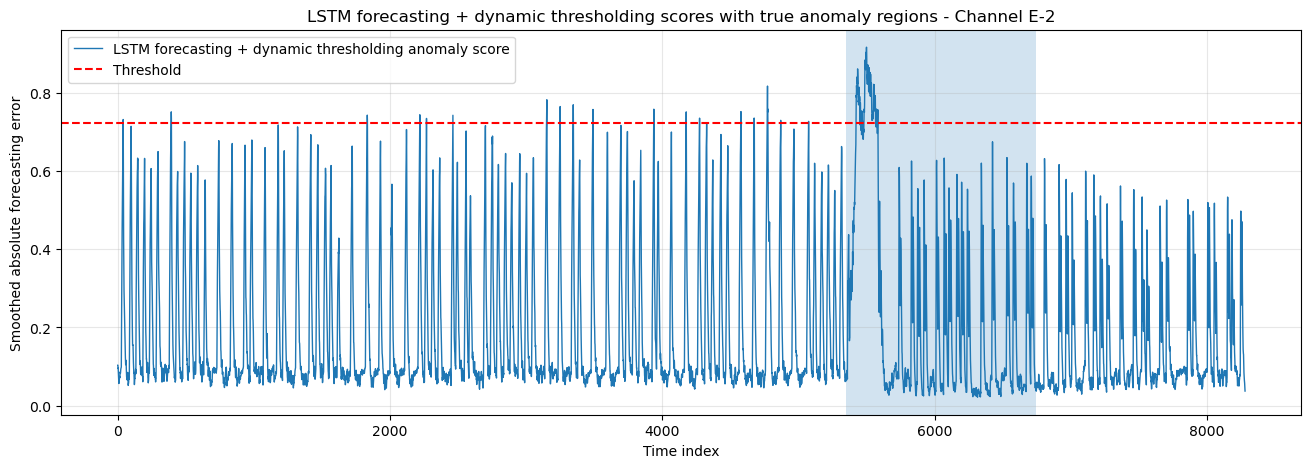

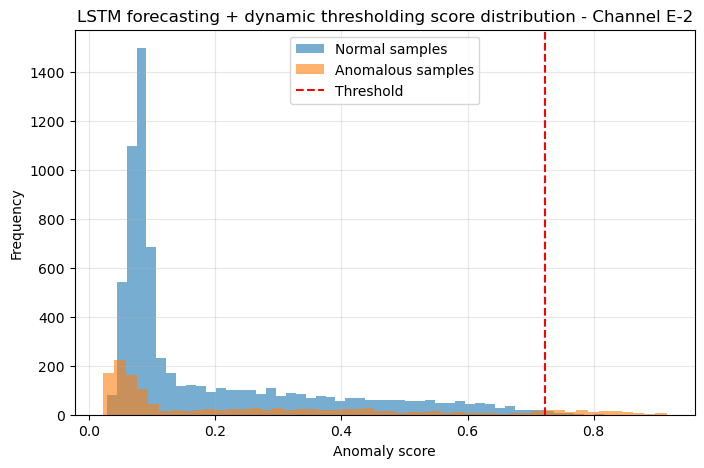

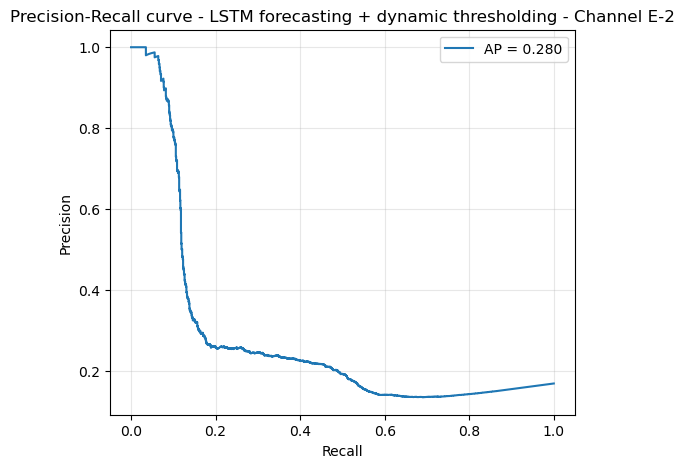

In [43]:
plot_scores_with_anomaly_regions(
    scores=scores_smooth,
    y_true=y_test_lstm_labels,
    threshold=lstm_threshold_plot,
    channel_id=channel_id,
    model_name="LSTM forecasting + dynamic thresholding",
    xlabel="Time index",
    score_label="Smoothed absolute forecasting error"
)

plot_score_distribution(
    scores=scores_smooth,
    y_true=y_test_lstm_labels,
    threshold=lstm_threshold_plot,
    channel_id=channel_id,
    model_name="LSTM forecasting + dynamic thresholding"
)

plot_pr_curve(
    scores=scores_smooth,
    y_true=y_test_lstm_labels,
    channel_id=channel_id,
    model_name="LSTM forecasting + dynamic thresholding"
)